<a href="https://colab.research.google.com/github/anyavaniprakash-spec/FTI-DSRP-Arms-Tranfers/blob/main/dsrp_Day_5_updated_topic_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 5

In [3]:
import pandas as pd
import csv
import io
import numpy as np
!pip install matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score
import warnings
warnings.filterwarnings('ignore')
!pip install seaborn
import seaborn as sns

In [4]:
url = 'https://raw.githubusercontent.com/frontiertechinstitute/datasets/main/Arms%20Transfers/arms_transfers_clean.csv'
df = pd.read_csv(url)

In [5]:
df.head()

,Recipient,Supplier,Year of order,Number ordered,Weapon designation,Weapon description,Deliveries in the Year Range,Year(s) of delivery,status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,United States,2015,55.0,M-1117 Guardian,armoured personnel carrier,55.0,2015,New,0.40,22.0,22.0
1,Afghanistan,United States,2004,188.0,M-113,armoured personnel carrier,188.0,2005,Second hand,0.10,18.8,18.8
2,Afghanistan,United States,2017,1673.0,HMMWV-UA,armoured personnel carrier,1673.0,2018; 2019; 2020; 2021,Second hand,0.05,87.0,87.0
3,Afghanistan,United States,2006,800.0,HMMWV-UA,armoured personnel carrier,800.0,2007; 2008,Second hand,0.05,41.6,41.6
4,Afghanistan,United States,2011,41.0,M-1117 Guardian,armoured personnel carrier,41.0,2011; 2012,New,0.40,16.4,16.4


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9756 entries, 0 to 9755
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       9756 non-null   object 
 1   Supplier                        9756 non-null   object 
 2   Year of order                   9756 non-null   int64  
 3   Number ordered                  9670 non-null   float64
 4   Weapon designation              9756 non-null   object 
 5   Weapon description              9756 non-null   object 
 6   Deliveries in the Year Range    9333 non-null   float64
 7   Year(s) of delivery             9333 non-null   object 
 8   status                          9756 non-null   object 
 9   SIPRI TIV per unit              9756 non-null   float64
 10  SIPRI TIV for total order       9756 non-null   float64
 11  SIPRI TIV of delivered weapons  9756 non-null   float64
dtypes: float64(5), int64(1), object(6)

,Year of order,Number ordered,Deliveries in the Year Range,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
count,9756.000000,9670.000000,9333.000000,9756.000000,9756.000000,9756.000000
mean,1987.274703,156.860703,154.585664,7.443830,94.357230,83.811894
std,22.060454,987.060460,997.650698,23.468209,337.544437,303.717951
min,1940.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1969.000000,3.000000,3.000000,0.240000,5.000000,4.200000
50%,1986.000000,12.000000,12.000000,1.000000,18.000000,16.000000
75%,2008.000000,60.000000,57.000000,5.000000,56.000000,52.575000
max,2025.000000,50000.000000,50000.000000,700.000000,10117.500000,10117.500000


In [7]:
df.isna().sum()

,0
Recipient,0
Supplier,0
Year of order,0
Number ordered,86
Weapon designation,0
Weapon description,0
Deliveries in the Year Range,423
Year(s) of delivery,423
status,0
SIPRI TIV per unit,0


In [8]:
df.dtypes

,0
Recipient,object
Supplier,object
Year of order,int64
Number ordered,float64
Weapon designation,object
Weapon description,object
Deliveries in the Year Range,float64
Year(s) of delivery,object
status,object
SIPRI TIV per unit,float64


In [9]:
df['Number ordered'] = pd.to_numeric(df['Number ordered'], errors='coerce')
df['Deliveries in the Year Range'] = pd.to_numeric(df['Deliveries in the Year Range'], errors='coerce')
df['Year(s) of delivery'] = pd.to_numeric(df['Year(s) of delivery'], errors='coerce')


In [10]:
# 1. Check the true data type
print("Data Type:", df['Year(s) of delivery'].dtype)

# 2. Check the exact count of missing values
print("Total Nulls:", df['Year(s) of delivery'].isnull().sum())

# 3. Look at a few rows where the data IS null
print("\nSample of Null Rows:")
print(df[df['Year(s) of delivery'].isnull()]['Year(s) of delivery'].head())


Data Type: float64
Total Nulls: 4834

Sample of Null Rows:
2   NaN
3   NaN
4   NaN
5   NaN
7   NaN
Name: Year(s) of delivery, dtype: float64


In [11]:
df.duplicated().sum()

np.int64(17)

In [12]:
df[df.duplicated()]

,Recipient,Supplier,Year of order,Number ordered,Weapon designation,Weapon description,Deliveries in the Year Range,Year(s) of delivery,status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
560,Bahrain,United States,1985,6.0,F-5E Tiger-2,fighter/ground-attack aircraft,6.0,NaN,New,10.50,63.00,63.00
1463,Colombia,United States,2010,1.0,King Air,light transport aircraft,1.0,2011.0,New,2.85,2.85,2.85
1903,Ecuador,United States,1980,1.0,King Air,light transport aircraft,1.0,1981.0,New,2.85,2.85,2.85
2141,Egypt,United States,1982,300.0,AIM-9L Sidewinder,short-range air-to-air missile,300.0,1983.0,New,0.11,33.00,33.00
2205,El Salvador,United States,1977,1.0,DC-6/C-118,transport aircraft,1.0,1977.0,Second hand,3.40,3.40,3.40
4328,Japan,United States,2001,16.0,SM-2MR,surface-to-air missile,16.0,2003.0,New,0.30,4.80,4.80
4938,Mexico,United States,2008,4.0,aircraft engine,aircraft engine,4.0,2010.0,New,0.50,2.00,2.00
5023,Mexico,United States,2010,3.0,S-70 Black Hawk,transport helicopter,3.0,2011.0,New,7.25,21.75,21.75
5277,Netherlands,United States,2009,14.0,vehicle engine,vehicle engine,14.0,2009.0,New,0.03,0.42,0.42
5340,Netherlands,United States,2023,NaN,AGM-114 Hellfire-2,anti-tank/air-to-surface missile,NaN,NaN,New,0.05,0.00,0.00


In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.rename(columns={'Year of order': 'Year of Order', 'Number ordered': 'Number Ordered', 'Weapon designation': 'Weapon Designation', 'Weapon description': 'Weapon Description', 'status': 'Status'}, inplace=True)
print(df.columns)


Index(['Recipient', 'Supplier', 'Year of Order', 'Number Ordered',
       'Weapon Designation', 'Weapon Description',
       'Deliveries in the Year Range', 'Year(s) of delivery', 'Status',
       'SIPRI TIV per unit', 'SIPRI TIV for total order',
       'SIPRI TIV of delivered weapons'],
      dtype='object')


R.Q: How has the volume, composition, and status of U.S-supplied major conventional weapons differed between Ukraine (Strategic Partner) and Israel (Major Non-NATO Ally) during each states conflicts, respectively?


Goals:

- Line graph showing count of weapons supplied over time (last five years)
- Multi Bar plot showing unique types of weapon descriptors for each country over time
- Filter all weapons into 3-5 categories…look at sipri page
- Tri- bar plot showing makeup of new v secondhand  for each country over time  
- Plot showing makeup of new v secondhand for each weapon for each country
- Calculate t-test between count of weapons for each country
- Model : based on three variables, can model classify correct recipient as ukraine or israel? - will show correlation


In [16]:
df_filtered = df[(df['Year of Order'] >= 2021) & (df['Supplier'] == 'United States') & (df['Recipient'].isin(['Ukraine', 'Israel']))]

In [17]:
df_filtered.groupby('Year of Order')['Deliveries in the Year Range'].sum()
df_filtered.groupby('Year of Order')['Number Ordered'].sum()

,Number Ordered
Year of Order,
2021,3308.0
2022,74639.0
2023,2913.0
2024,886.0
2025,31230.0


In [18]:
one = df_filtered.groupby('Year of Order')['Deliveries in the Year Range'].sum()
two = df_filtered.groupby('Year of Order')['Number Ordered'].sum()

Text(0.5, 1.0, 'US Arms Transfers to Ukraine and Israel (2021-2025)')

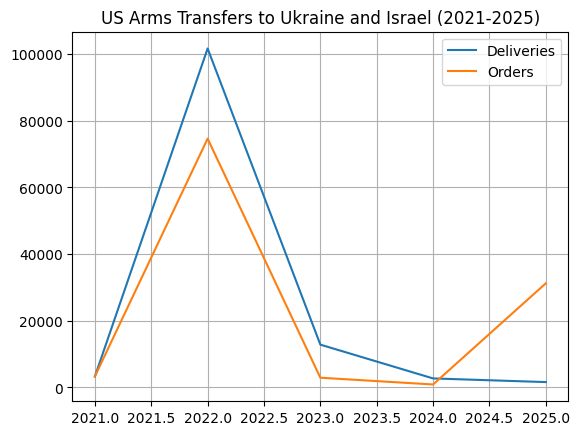

In [19]:
plt.plot(one.index, one, label = 'Deliveries')
plt.plot(two.index, two, label = 'Orders')
plt.grid(True)
plt.legend()

plt.title('US Arms Transfers to Ukraine and Israel (2021-2025)')

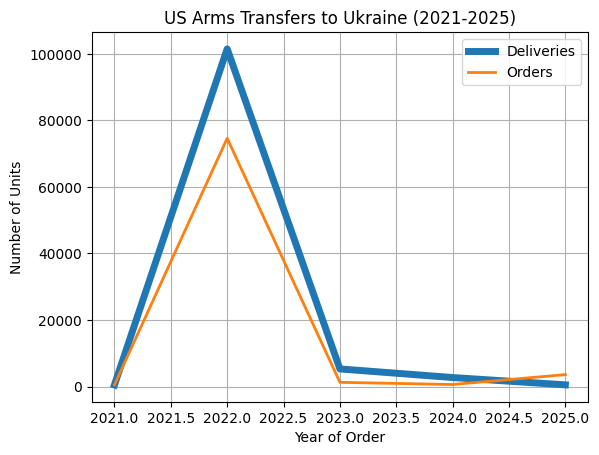

In [20]:

# Data for Ukraine
df_ukraine = df_filtered[df_filtered['Recipient'] == 'Ukraine']
ukraine_deliveries = df_ukraine.groupby('Year of Order')['Deliveries in the Year Range'].sum()
ukraine_orders = df_ukraine.groupby('Year of Order')['Number Ordered'].sum()

# Plot for Ukraine
plt.plot(ukraine_deliveries.index, ukraine_deliveries, label='Deliveries', linewidth = 5)
plt.plot(ukraine_orders.index, ukraine_orders, label='Orders', linewidth = 2)
plt.title('US Arms Transfers to Ukraine (2021-2025)')
plt.xlabel('Year of Order')
plt.ylabel('Number of Units')
plt.legend()
plt.grid(True)


As the threat of a full-scale invasion grew in late 2021, the Biden administration quietly accelerated these transfers. Between September 2021 and the February 2022 invasion, the U.S. sent multiple shipments containing shotguns, ammunition, and highly effective anti-aircraft and anti-armor systems like Stinger and Javelin missiles - Stimson Center, US Dept of War

(0.0, 100000.0)

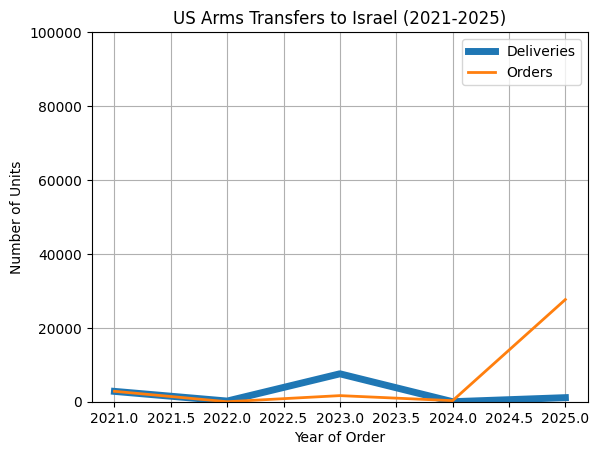

In [23]:
# Data for Israel
df_israel = df_filtered[df_filtered['Recipient'] == 'Israel']
israel_deliveries = df_israel.groupby('Year of Order')['Deliveries in the Year Range'].sum()
israel_orders = df_israel.groupby('Year of Order')['Number Ordered'].sum()

# Plot for Israel
plt.plot(israel_deliveries.index, israel_deliveries, label='Deliveries', linewidth = 5)
plt.plot(israel_orders.index, israel_orders, label='Orders', linewidth = 2)
plt.title('US Arms Transfers to Israel (2021-2025)')
plt.xlabel('Year of Order')
plt.ylabel('Number of Units')
plt.legend()
plt.grid(True)
plt.ylim(0, 100000)


# can continue experimenting with line width...

the US was regularly transferring lethal arms and military equipment to Israel before the October 7, 2023, Hamas attack. These transfers were part of a long-standing 10-year Memorandum of Understanding (MOU) signed in 2016, which provided Israel with roughly $3.8 billion in annual military assistance.Before October 2023, these routine US-supplied arsenals to the Israel Defense Forces (IDF) consisted primarily of advanced combat aircraft (such as F-15s, F-16s, and F-35s), transport and attack helicopters, precision-guided munitions, air defense interceptors for the Iron Dome, and various categories of ammunition. Additionally, the US maintained War Reserves Stock Allies-Israel—a stockpile of US-owned weapons located in Israel that is accessible to the IDF during emergencies. - Brown Uni

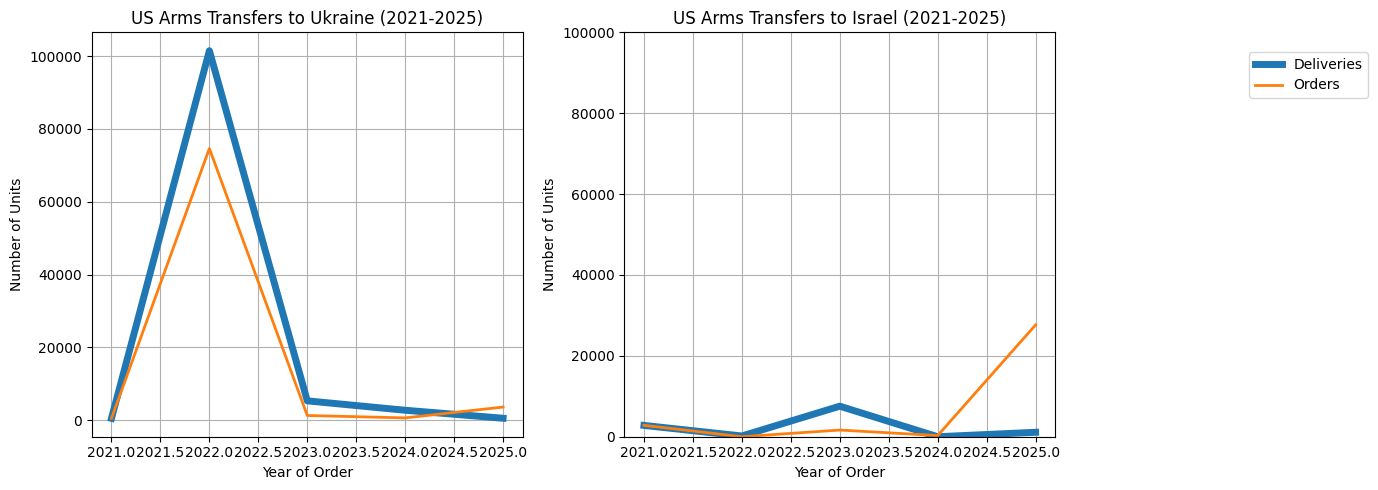

In [65]:
# format of above two plots if we put them next to each other using axes.set_ code

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

df_ukraine = df_filtered[df_filtered['Recipient'] == 'Ukraine']
ukraine_deliveries = df_ukraine.groupby('Year of Order')['Deliveries in the Year Range'].sum()
ukraine_orders = df_ukraine.groupby('Year of Order')['Number Ordered'].sum()

# Plot for Ukraine
axes[0].plot(ukraine_deliveries.index, ukraine_deliveries, label='Deliveries', linewidth = 5)
axes[0].plot(ukraine_orders.index, ukraine_orders, label='Orders', linewidth = 2)
axes[0].set_title('US Arms Transfers to Ukraine (2021-2025)')
axes[0].set_xlabel('Year of Order')
axes[0].set_ylabel('Number of Units')
axes[0].grid(True)

df_israel = df_filtered[df_filtered['Recipient'] == 'Israel']
israel_deliveries = df_israel.groupby('Year of Order')['Deliveries in the Year Range'].sum()
israel_orders = df_israel.groupby('Year of Order')['Number Ordered'].sum()

# Plot for Israel
axes[1].plot(israel_deliveries.index, israel_deliveries, label='Deliveries', linewidth = 5)
axes[1].plot(israel_orders.index, israel_orders, label='Orders', linewidth = 2)
axes[1].set_title('US Arms Transfers to Israel (2021-2025)')
axes[1].set_xlabel('Year of Order')
axes[1].set_ylabel('Number of Units')
axes[1].grid(True)
axes[1].set_ylim(0, 100000)

fig.legend(['Deliveries', 'Orders'], loc='upper right', bbox_to_anchor=(1.15, 0.9))
fig.tight_layout(rect=[0, 0, 0.9, 1])
fig.show()

In [24]:
df_filtered[df_filtered['Deliveries in the Year Range'] != df_filtered['Number Ordered']]
#Note: some entries may have number ordered>deliveries because the weapons are still being delivered and the database has not been updated with the new info
#(many entries are also missing values)

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
3467,Israel,United States,2025,2166.0,GBU-39 SDB,guided glide bomb,100.0,2025.0,New,0.02,43.32,2.00
3470,Israel,United States,2025,3000.0,AGM-114 Hellfire-2,anti-tank/air-to-surface missile,NaN,NaN,New,0.05,150.00,0.00
3471,Israel,United States,2025,17479.0,JDAM,guided bomb,1000.0,2025.0,New,0.02,349.58,20.00
3472,Israel,United States,2022,NaN,Terrier LT-79,armoured personnel carrier,NaN,NaN,New,0.14,0.00,0.00
3481,Israel,United States,2021,4.0,KC-46A Pegasus,tanker/transport aircraft,NaN,NaN,New,90.00,360.00,0.00
3623,Israel,United States,2024,25.0,APG-82,combat aircraft radar,NaN,NaN,New,2.50,62.50,0.00
3624,Israel,United States,2021,12.0,CH-53K King Stallion,transport helicopter,NaN,NaN,New,0.00,0.00,0.00
3682,Israel,United States,2025,5000.0,JDAM,guided bomb,NaN,NaN,New,0.02,100.00,0.00
3683,Israel,United States,2024,10.0,F-110,turbofan,NaN,NaN,New,3.25,32.50,0.00
3699,Israel,United States,2024,25.0,F-35A Lightning-2,fighter/ground-attack aircraft,NaN,NaN,New,55.00,1375.00,0.00


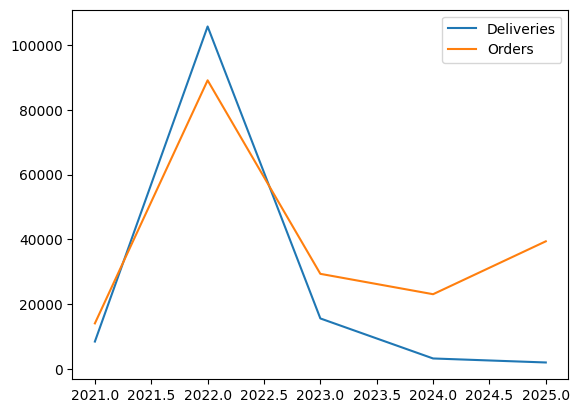

In [72]:
# looking at U.S supply to all countries and seeing distribution of number ordered v deliveries

df_US_five = df[(df['Supplier']=='United States') & (df['Year of Order'] >= 2021)]
df_US_five.groupby('Year of Order')['Deliveries in the Year Range']
df_US_five.groupby('Year of Order')['Number Ordered']
US_one = df_US_five.groupby('Year of Order')['Deliveries in the Year Range'].sum()
US_two = df_US_five.groupby('Year of Order')['Number Ordered'].sum()

plt.plot(US_one.index, US_one.values, label = 'Deliveries')
plt.plot(US_two.index, US_two.values, label = 'Orders')
plt.legend()
plt.show()

# note: this is for all recipients of US arms transfers, not just Ukraine and Israel (that was the first plot we made)
# we can attribute this similar variation compared to Ukraine and Israel with the fact that Ukraine and Israel received the most weapons from the US
# interesting difference around 2023-2024 though (there were proabably other countries ordering a lot of weapons and US supplied less...)

In [29]:
df_filtered['Weapon Description'].unique()

array(['guided glide bomb', 'anti-tank/air-to-surface missile',
       'guided bomb', 'armoured personnel carrier',
       'tanker/transport aircraft', 'combat aircraft radar',
       'transport helicopter', 'turbofan',
       'fighter/ground-attack aircraft', 'surface-to-air missile system',
       'surface-to-air missile', 'aircraft engine', 'multi-role radar',
       'one-way attack drone', 'anti-tank missile', 'air-search radar',
       'infantry fighting vehicle', 'portable surface-to-air missile',
       'artillery locating radar', 'self-propelled gun', 'towed gun',
       'tank', 'air-to-surface missile', 'patrol boat',
       'anti-ballistic missile missile',
       'mobile surface-to-air missile system', 'loitering munition',
       'guided rocket', 'armoured recovery vehicle',
       'short-range air-to-air missile', 'surface-to-surface missile',
       'multiple rocket launcher', 'mortar',
       'long-range air-to-air missile', 'vehicle engine',
       'anti-radar missile',

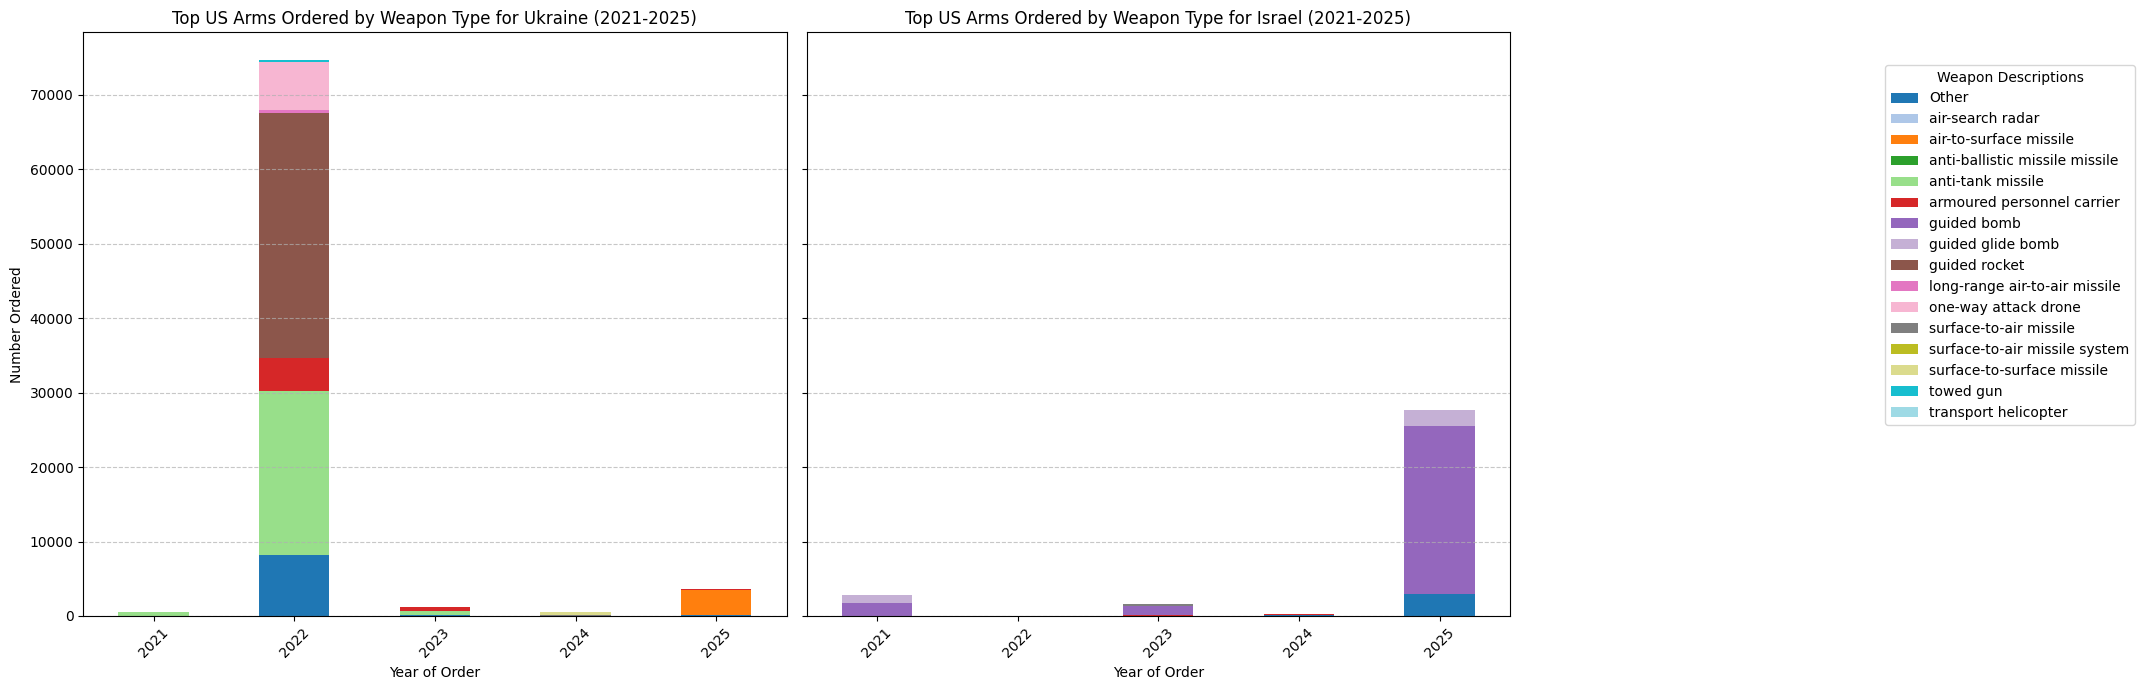

In [159]:
### lots of data vis ------------------>
# Defining weapon categorization
def get_weapon_category(description):
    description = str(description).lower()
    if 'aircraft' in description or 'helicopter' in description or 'turbofan' in description or 'radar' in description or 'patrol boat' in description:
        return 'Aircraft/Aircraft Systems'
    elif 'missile' in description or 'bomb' in description or 'rocket' in description or 'munition' in description or 'drone' in description or 'shell' in description or 'mortar' in description:
        return 'Missiles/Rockets/Ammunition'
    elif 'armoured' in description or 'tank' in description or 'gun' in description or 'vehicle' in description or 'bridgelayer' in description:
        return 'Armoured Vehicles/Artillery'
    else:
        return 'Other/Support'

# Applying categories
df_filtered['Weapon Category'] = df_filtered['Weapon Description'].apply(get_weapon_category)

all_weapon_counts = df_filtered['Weapon Description'].value_counts()
top_n = 15
top_n_weapons = all_weapon_counts.head(top_n).index.tolist()

def categorize_weapon(description, top_n_list):
    if description in top_n_list:
        return description
    return 'Other'

# Apply categorization for each country
df_ukraine_weapons = df_filtered[df_filtered['Recipient'] == 'Ukraine'].copy()
df_ukraine_weapons['Categorized Weapon'] = df_ukraine_weapons['Weapon Description'].apply(lambda x: categorize_weapon(x, top_n_weapons))

df_israel_weapons = df_filtered[df_filtered['Recipient'] == 'Israel'].copy()
df_israel_weapons['Categorized Weapon'] = df_israel_weapons['Weapon Description'].apply(lambda x: categorize_weapon(x, top_n_weapons))

# groupby!
ukraine_weapon_data_plot = df_ukraine_weapons.groupby(['Year of Order', 'Categorized Weapon'])['Number Ordered'].sum().unstack(fill_value=0)
israel_weapon_data_plot = df_israel_weapons.groupby(['Year of Order', 'Categorized Weapon'])['Number Ordered'].sum().unstack(fill_value=0)

# Include 'Other' and make sure all columns are in a consistent order for legend colors
all_legend_items = sorted(list(set(top_n_weapons + ['Other'])))

# include all possible legend items, filling with 0 if missing (NaN values that we added earlier in the notebook/earlier in the week)
# Note - make sure to include this in dataset/methodology section
for col in all_legend_items:
    if col not in ukraine_weapon_data_plot.columns:
        ukraine_weapon_data_plot[col] = 0
    if col not in israel_weapon_data_plot.columns:
        israel_weapon_data_plot[col] = 0

ukraine_weapon_data_plot = ukraine_weapon_data_plot[all_legend_items]
israel_weapon_data_plot = israel_weapon_data_plot[all_legend_items]

# subplots--->
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# plt/map color info --->
cmap = plt.get_cmap('tab20') # 'tab20' can handle up to 20 distinct colors (according to google...)
colors = [cmap(i) for i in np.linspace(0, 1, len(all_legend_items))]
color_dict = dict(zip(all_legend_items, colors))

# plot for Ukraine
ukraine_weapon_data_plot.plot(kind='bar', stacked=True, ax=axes[0],
                                 color=[color_dict[col] for col in ukraine_weapon_data_plot.columns])
axes[0].set_title('Top US Arms Ordered by Weapon Type for Ukraine (2021-2025)')
axes[0].set_xlabel('Year of Order')
axes[0].set_ylabel('Number Ordered')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].get_legend().remove()

# plot for Israel
israel_weapon_data_plot.plot(kind='bar', stacked=True, ax=axes[1],
                                color=[color_dict[col] for col in israel_weapon_data_plot.columns])
axes[1].set_title('Top US Arms Ordered by Weapon Type for Israel (2021-2025)')
axes[1].set_xlabel('Year of Order')
axes[1].set_ylabel('Number Ordered')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].get_legend().remove()

# can do separate plots but makes more sense when they are next to each other (that's why we use the axes.set_ and not the plt.)

# lengend --->
legend_patches = [plt.Rectangle((0,0),1,1, fc=color_dict[label]) for label in all_legend_items]
fig.legend(legend_patches, all_legend_items, title='Weapon Descriptions',
           bbox_to_anchor=(1.05, 0.9), loc='upper left', borderaxespad=0.)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [37]:
## Confirming info in plots above

print("Total 'Number Ordered' by Categorized Weapon for Ukraine:")
print(df_ukraine_weapons.groupby('Categorized Weapon')['Number Ordered'].sum())

print("\nTotal 'Number Ordered' by Categorized Weapon for Israel:")
print(df_israel_weapons.groupby('Categorized Weapon')['Number Ordered'].sum())

Total 'Number Ordered' by Categorized Weapon for Ukraine:
Categorized Weapon
Other                              8427.0
air-search radar                     25.0
air-to-surface missile             3350.0
anti-ballistic missile missile        0.0
anti-tank missile                 23080.0
armoured personnel carrier         5063.0
guided glide bomb                     0.0
guided rocket                     32900.0
long-range air-to-air missile       325.0
one-way attack drone               6520.0
surface-to-air missile               90.0
surface-to-air missile system        14.0
surface-to-surface missile          500.0
towed gun                           255.0
transport helicopter                 23.0
Name: Number Ordered, dtype: float64

Total 'Number Ordered' by Categorized Weapon for Israel:
Categorized Weapon
Other                             3095.0
armoured personnel carrier         350.0
guided bomb                      25479.0
guided glide bomb                 3166.0
surface-to-air 

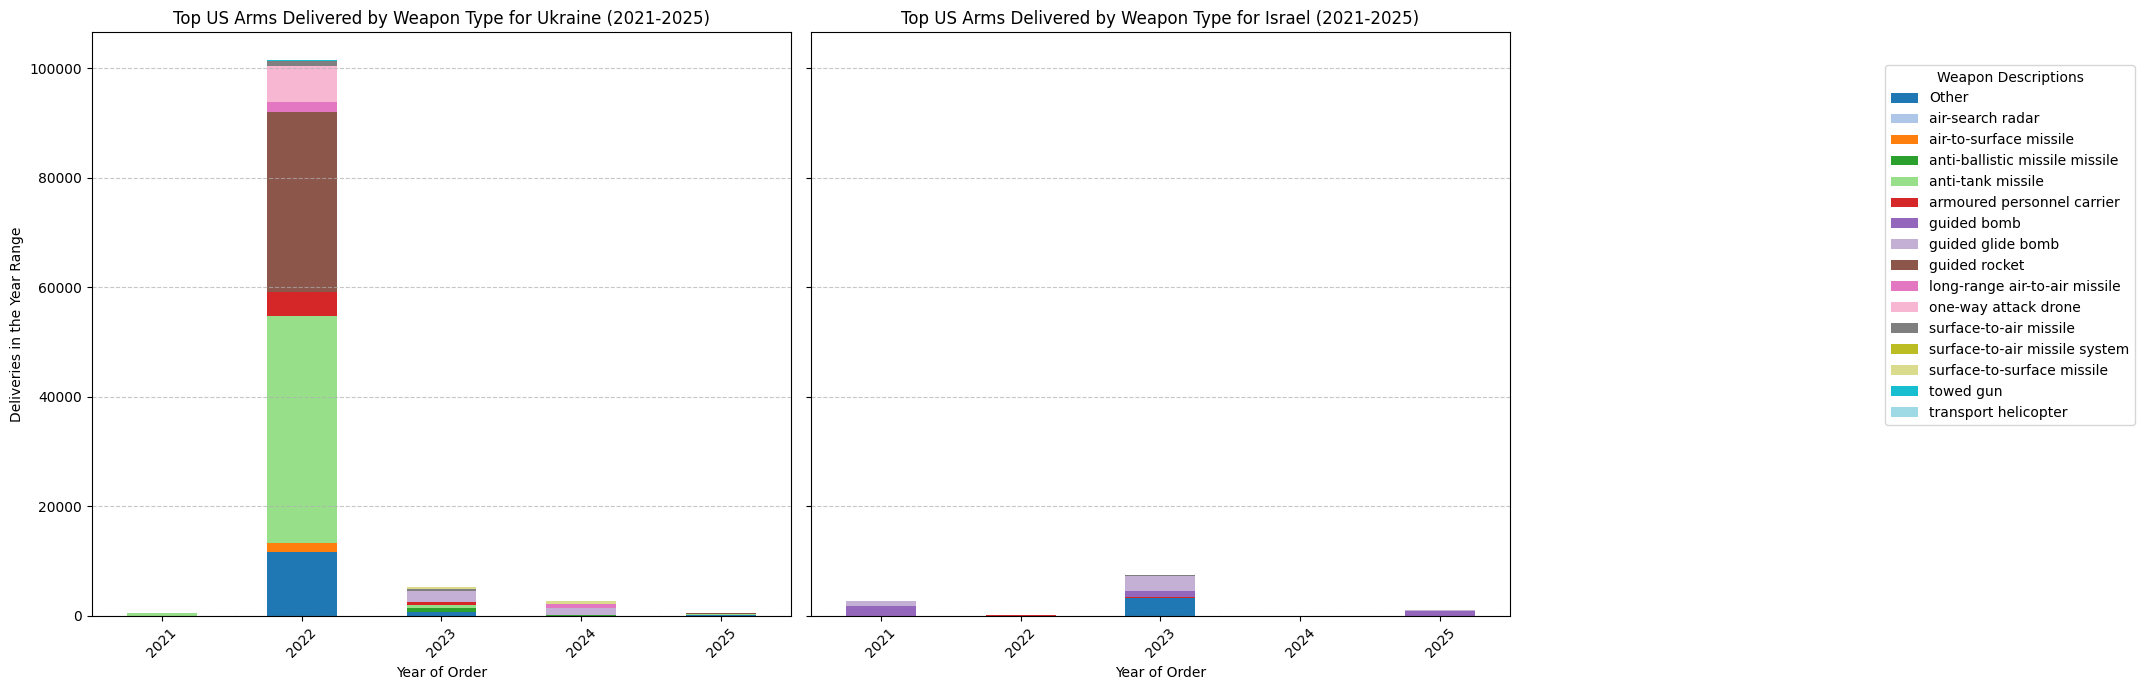

In [158]:
# Defining weapon categorization
def get_weapon_category(description):
    description = str(description).lower()
    if 'aircraft' in description or 'helicopter' in description or 'turbofan' in description or 'radar' in description or 'patrol boat' in description:
        return 'Aircraft/Aircraft Systems'
    elif 'missile' in description or 'bomb' in description or 'rocket' in description or 'munition' in description or 'drone' in description or 'shell' in description or 'mortar' in description:
        return 'Missiles/Rockets/Ammunition'
    elif 'armoured' in description or 'tank' in description or 'gun' in description or 'vehicle' in description or 'bridgelayer' in description:
        return 'Armoured Vehicles/Artillery'
    else:
        return 'Other/Support'


df_filtered['Weapon Category'] = df_filtered['Weapon Description'].apply(get_weapon_category)


all_weapon_counts = df_filtered['Weapon Description'].value_counts()
top_n = 15
top_n_weapons = all_weapon_counts.head(top_n).index.tolist()


def categorize_weapon(description, top_n_list):
    if description in top_n_list:
        return description
    return 'Other'

# Apply categorization for each country
df_ukraine_weapons = df_filtered[df_filtered['Recipient'] == 'Ukraine'].copy()
df_ukraine_weapons['Categorized Weapon'] = df_ukraine_weapons['Weapon Description'].apply(lambda x: categorize_weapon(x, top_n_weapons))

df_israel_weapons = df_filtered[df_filtered['Recipient'] == 'Israel'].copy()
df_israel_weapons['Categorized Weapon'] = df_israel_weapons['Weapon Description'].apply(lambda x: categorize_weapon(x, top_n_weapons))

# groupby! -- but we're doing deliveries not order!!
ukraine_weapon_data_plot = df_ukraine_weapons.groupby(['Year of Order', 'Categorized Weapon'])['Deliveries in the Year Range'].sum().unstack(fill_value=0)
israel_weapon_data_plot = df_israel_weapons.groupby(['Year of Order', 'Categorized Weapon'])['Deliveries in the Year Range'].sum().unstack(fill_value=0)

# Include 'Other' and make sure all columns are in a consistent order for legend colors
all_legend_items = sorted(list(set(top_n_weapons + ['Other'])))

# include all possible legend items, filling with 0 if missing (NaN values that we added earlier in the notebook/earlier in the week)
# Note - make sure to include this in dataset/methodology section
for col in all_legend_items:
    if col not in ukraine_weapon_data_plot.columns:
        ukraine_weapon_data_plot[col] = 0
    if col not in israel_weapon_data_plot.columns:
        israel_weapon_data_plot[col] = 0

ukraine_weapon_data_plot = ukraine_weapon_data_plot[all_legend_items]
israel_weapon_data_plot = israel_weapon_data_plot[all_legend_items]

# subplots--->
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# plt/map color info --->
cmap = plt.get_cmap('tab20') # 'tab20' can handle up to 20 distinct colors (according to google...)
colors = [cmap(i) for i in np.linspace(0, 1, len(all_legend_items))]
color_dict = dict(zip(all_legend_items, colors))

# plot for Ukraine
ukraine_weapon_data_plot.plot(kind='bar', stacked=True, ax=axes[0],
                                 color=[color_dict[col] for col in ukraine_weapon_data_plot.columns])
axes[0].set_title('Top US Arms Delivered by Weapon Type for Ukraine (2021-2025)')
axes[0].set_xlabel('Year of Order')
axes[0].set_ylabel('Deliveries in the Year Range')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].get_legend().remove()

# plot for Israel
israel_weapon_data_plot.plot(kind='bar', stacked=True, ax=axes[1],
                                color=[color_dict[col] for col in israel_weapon_data_plot.columns])
axes[1].set_title('Top US Arms Delivered by Weapon Type for Israel (2021-2025)')
axes[1].set_xlabel('Year of Order')
axes[1].set_ylabel('Deliveries in the Year Range')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].get_legend().remove()

# lengend --->
legend_patches = [plt.Rectangle((0,0),1,1, fc=color_dict[label]) for label in all_legend_items]
fig.legend(legend_patches, all_legend_items, title='Weapon Descriptions',
           bbox_to_anchor=(1.05, 0.9), loc='upper left', borderaxespad=0.)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# good to show this plot next to the plot showing the Number Ordered -- there are differences

In [47]:
## Confirming this info to --->

print("Total 'Deliveries in the Year Range' by Categorized Weapon for Ukraine:")
print(df_ukraine_weapons.groupby('Categorized Weapon')['Deliveries in the Year Range'].sum())

print("\nTotal 'Deliveries in the Year Range' by Categorized Weapon for Israel:")
print(df_israel_weapons.groupby('Categorized Weapon')['Deliveries in the Year Range'].sum())

Total 'Deliveries in the Year Range' by Categorized Weapon for Ukraine:
Categorized Weapon
Other                             12654.0
air-search radar                     17.0
air-to-surface missile             1550.0
anti-ballistic missile missile      850.0
anti-tank missile                 42680.0
armoured personnel carrier         4933.0
guided glide bomb                  3250.0
guided rocket                     33100.0
long-range air-to-air missile      2575.0
one-way attack drone               6520.0
surface-to-air missile             1215.0
surface-to-air missile system        11.0
surface-to-surface missile          850.0
towed gun                           255.0
transport helicopter                 23.0
Name: Deliveries in the Year Range, dtype: float64

Total 'Deliveries in the Year Range' by Categorized Weapon for Israel:
Categorized Weapon
Other                            3300.0
armoured personnel carrier        329.0
guided bomb                      4000.0
guided glide bomb

In [41]:
df_filtered['Status'].value_counts()

# ok so no 'second hand but modernized' label (We saw this a few times in the csv file/OG df)

,count
Status,
Second hand,58
New,54


In [42]:
df['Status'].value_counts()

# ok there weren't that many in the OG df anyway

,count
Status,
New,6995
Second hand,2594
Second hand but modernized,150


In [43]:
df_filtered['Status']

,Status
3467,New
3470,New
3471,New
3472,New
3481,New
...,...
8904,New
8905,Second hand
8906,Second hand
8907,New


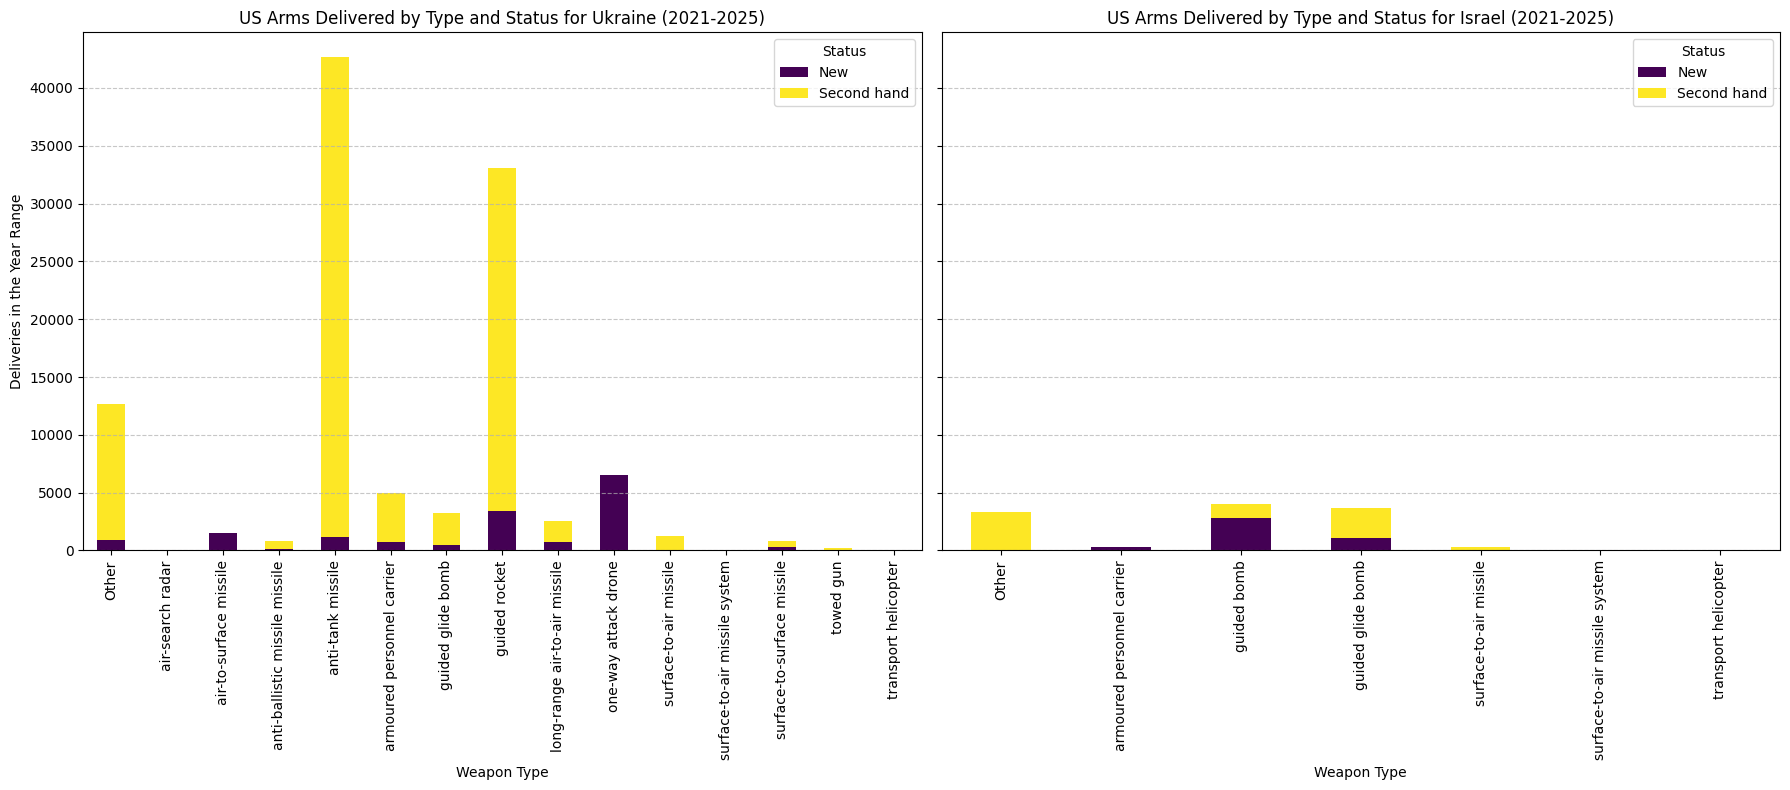

In [46]:

# Group by Categorized Weapon and Status, then sum 'Number Ordered'
ukraine_status_data = df_ukraine_weapons.groupby(['Categorized Weapon', 'Status'])['Deliveries in the Year Range'].sum().unstack(fill_value=0)
israel_status_data = df_israel_weapons.groupby(['Categorized Weapon', 'Status'])['Deliveries in the Year Range'].sum().unstack(fill_value=0)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# Plot for Ukraine
ukraine_status_data.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title('US Arms Delivered by Type and Status for Ukraine (2021-2025)')
axes[0].set_xlabel('Weapon Type')
axes[0].set_ylabel('Deliveries in the Year Range')
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(title='Status')


# Plot for Israel
israel_status_data.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('US Arms Delivered by Type and Status for Israel (2021-2025)')
axes[1].set_xlabel('Weapon Type')
axes[1].set_ylabel('Deliveries in the Year Range')
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()

# initially had 'Number Ordered' but this didn't make sense - and it gave double the amount of weapons count for Israel which was false info!
# change to deliveries in the year range because countries aren't specifying/don't choose weapon status when ordering them

# Plot Analysis:
# Ukraine get's a lot of second hand - but they are also getting a lot more weapons
# important that Ukraine is getting lots of new one-way attack drones --> many articles talking about drone warfare/how Ukraine drones are being used a lot
# Israel getting a lot of new guided bombs --> can explore how these weapons reflect the nature of the conflict (or how nature of the conflict leads us to these weapons)

In [53]:
## last things before t-tests: finding difference in total weapons ordered and delivered
## for differences regarding specific weapons -- can use confirming print statements above

print ('Total Weapons Ordered by Ukraine:', df_ukraine_weapons['Number Ordered'].sum())
print ('Total Weapons Ordered by Israel:', df_israel_weapons['Number Ordered'].sum())

print ('Total Weapons Delivered to Ukraine:', df_ukraine_weapons['Deliveries in the Year Range'].sum())
print ('Total Weapons Delivered to Israel:', df_israel_weapons['Deliveries in the Year Range'].sum())

# remember all of this is when the US is the supplier and it's between the years 2021-2025 (max year of dataset)
# can use these numbers for exact data comparisons...

Total Weapons Ordered by Ukraine 80572.0
Total Weapons Ordered by Israel 32404.0
Total Weapons Delivered to Ukraine 110483.0
Total Weapons Delivered to Israel 11631.0


T-Test / Finding Statistical Significance....

- *comparing Ukraine Deliveries and Israel Deliveries*
- *comparing number of unique weapons for Ukraine vs. Israel*
- *comparing Ukraine count of new vs. Isreal count of new*
- *comparing Ukraine count of second hand vs. Isreal count of second hand*

- can we compare number ordered to number delivered for each country -- can also just use data visual for this

These are all numerical...

** so will proabably be running 2 sample t-test - measures whether the mean of one group differs from the mean of another group **

- could do paired 2 sample test if we want to look at across time...but five years isn't that long ... and we could just look at data plots

In [73]:
!pip install scipy
import scipy.stats as stats

In [ ]:
# t_stat, p_val = stats.ttest_ind(group1,group2)
# t_stat, p_val = stats.ttest_ind(group1, group2, alternative = "less")

# Day 5-6

here we're revieweing our null values in the filtered and in the original dataset(before we changed null to NaN) because to run the ttest we have to drop any null / na values

- this is good to come back to for exact missing data numbers and limitations in data analysis

- all the data reflected by the data visuals and ttest is the same (they both just skip / omit the missing values in different ways)



In [97]:
df_filtered.isna().sum()

,0
Recipient,0
Supplier,0
Year of Order,0
Number Ordered,28
Weapon Designation,0
Weapon Description,0
Deliveries in the Year Range,17
Year(s) of delivery,64
Status,0
SIPRI TIV per unit,0


In [96]:
# Null values in the original DataFrame before filtering
print('NaN counts in original df:')
print(df.isna().sum())

NaN counts in original df:
Recipient                            0
Supplier                             0
Year of Order                        0
Number Ordered                      85
Weapon Designation                   0
Weapon Description                   0
Deliveries in the Year Range       422
Year(s) of delivery               4830
Status                               0
SIPRI TIV per unit                   0
SIPRI TIV for total order            0
SIPRI TIV of delivered weapons       0
dtype: int64


In [107]:
groups = df_filtered.groupby('Recipient')['Deliveries in the Year Range']
group1 = groups.get_group('Ukraine').dropna()
group2 = groups.get_group('Israel').dropna()

In [121]:
t_stat, p_val = stats.ttest_ind(group1, group2, alternative = "greater")

In [124]:
result = t_stat, p_val = stats.ttest_ind(group1, group2, alternative = "greater")

In [125]:
test_statistic = result.statistic

In [126]:
p_val = result.pvalue

In [127]:
print(test_statistic, p_val)

0.2734450282562569 0.3925587455031993


In [128]:
print('Standard deviation of Ukraine deliveries:', group1.std())
print('Standard deviation of Israel deliveries:', group2.std())

Standard deviation of Ukraine deliveries: 4545.696564180209
Standard deviation of Israel deliveries: 1095.4429676868374


This two-sample independent t-test above (with alternative='greater') was performed to see if the average 'Deliveries in the Year Range' to Ukraine is greater than that to Israel.

because p_val (0.392) > our threshold of significance (0.05) we fail to reject the null hypothesis.

t-test did not give statistically significant results

In [129]:
## next t-test ---->


groups = df_filtered.groupby('Recipient')['Number Ordered']
group1 = groups.get_group('Ukraine').dropna()
group2 = groups.get_group('Israel').dropna()

In [136]:
t_stat, p_val = stats.ttest_ind(group1, group2, alternative = "greater")
result = t_stat, p_val = stats.ttest_ind(group1, group2, alternative = "greater")
test_statistic = result.statistic
p_val = result.pvalue

In [137]:
print(test_statistic, p_val)

-0.31515071447906257 0.6232760870097587


fail to reject null hypothesis for above t-test

In [143]:
## next tests will be chi sqaure for weapons and status comparison


con_table = pd.crosstab(
        df_filtered["Recipient"], df_filtered["Weapon Description"])

In [144]:
result = stats.chi2_contingency(con_table)

In [150]:
chi2_stat = result.statistic
p_val = result.pvalue

In [149]:
expected_table = result.expected_freq

In [155]:
print(chi2_stat)
print(p_val)
print(expected_table)

66.18586612576064
0.005713869691003802
[[ 0.66964286  0.66964286  0.22321429  0.66964286  0.22321429  1.33928571
   0.44642857  0.22321429  0.22321429  3.79464286  0.22321429  0.22321429
   0.44642857  0.22321429  0.44642857  0.89285714  1.5625      0.66964286
   0.22321429  0.44642857  0.44642857  1.33928571  0.44642857  0.22321429
   0.44642857  0.44642857  0.89285714  0.22321429  0.22321429  0.22321429
   0.22321429  0.22321429  1.11607143  1.33928571  0.66964286  0.22321429
   0.44642857  0.66964286  0.66964286  0.22321429  0.44642857]
 [ 2.33035714  2.33035714  0.77678571  2.33035714  0.77678571  4.66071429
   1.55357143  0.77678571  0.77678571 13.20535714  0.77678571  0.77678571
   1.55357143  0.77678571  1.55357143  3.10714286  5.4375      2.33035714
   0.77678571  1.55357143  1.55357143  4.66071429  1.55357143  0.77678571
   1.55357143  1.55357143  3.10714286  0.77678571  0.77678571  0.77678571
   0.77678571  0.77678571  3.88392857  4.66071429  2.33035714  0.77678571
   1.55357

We reject the null hypothesis in the chi square above!

This means that there is a statistical significance when we compare the weapon description between ukraine and israel

In [160]:
## next chi square---->

con_table = pd.crosstab(
        df_filtered["Recipient"], df_filtered["Status"])

In [161]:
result = stats.chi2_contingency(con_table)

In [162]:
chi2_stat = result.statistic
p_val = result.pvalue

In [163]:
expected_table = result.expected_freq

In [164]:
print(chi2_stat)
print(p_val)
print(expected_table)

11.435867353679479
0.0007203983855544699
[[12.05357143 12.94642857]
 [41.94642857 45.05357143]]


p_val<0.05 so We reject the null hypothesis in the chi square above!

This means that there is a statistical significance when we compare the weapon status(new v secondhand) between ukraine and israel

next steps:

- double check t-test work above..
- prep for lightning talk on Monday
- continue lit review / save sources
- brainstorm potential classification/predictive models
  - maybe use feature importance tool to confirm significance of weapon description and status columns???